# Part 1. Set up the notebook
Authors: Marianna Foschi, Antonio Fuentes, Brandon Zhao (2026)

### Step 1: Enable the GPU runtime

1. In the Colab menu, click Runtime → Change runtime type
2. Under "Hardware accelerator", select T4 GPU
3. Click Save

### Step 2: Install packages

1. Run the following cell
2. A pop up window should appear, select "Restart session"
3. Rerun the cell and move on to the next one



In [ ]:
!pip install git+https://github.com/mariannafoschi/kine.git
!pip install jax[cuda12] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install ehtim finufft flax optax

  Cloning https://github.com/mariannafoschi/kine.git to /tmp/pip-req-build-4r26q8w1
  Running command git clone --filter=blob:none --quiet https://github.com/mariannafoschi/kine.git /tmp/pip-req-build-4r26q8w1
  Resolved https://github.com/mariannafoschi/kine.git to commit 9aee518fd6b7e6cf47221596bcfa6338161fbbe6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html


In [ ]:
import jax
print("JAX devices:", jax.devices())
print(jax.numpy.ones(3))

JAX devices: [CudaDevice(id=0)]
[1. 1. 1.]


### Step 3: Import packages

Ensure all packages load correctly

In [ ]:
import glob
import queue
import warnings
import numpy as np
import ehtim as eh
import ehtim.const_def as ehc
from tqdm.notebook import tqdm
from collections import OrderedDict as odict

import jax
import optax
from flax import linen as nn
from jax import numpy as jnp

import kine.model as mo
import kine.obsdata as ob
import kine.trainer as tr
import kine.utils as ut
import kine.video as vi

print("✓ All imports successful")
print("✓ GPU ready for kine")

Welcome to eht-imaging!


✓ All imports successful
✓ GPU ready for kine


**Note:** GPU-accelerated NUFFT is not available in colab but it is implemented in the code. It is designed for multi-epoch imaging of large datasets.

# Part 2. Upload observations and set imaging parameters
### Step 1: Upload observation file to Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hops_2017_M87.uvfits to hops_2017_M87.uvfits


### Step 2: Set imaging parameters
**Note:** In the actual code this is done by loading a .yaml file, but for this Colab tutorial we will set them directly in the notebook.

In [ ]:
# Data pre-processing
# -----------------------------
# Time averaging
tavg = 60
# Systematic noise
syserr = 0.01
# Minimum number of baselines per data snapshot
min_bl = 0

# Coordinates and data products
# -----------------------------
# Field of view (uas)
fov_uas = 200
# Space resolution (pix)
npix = 64
# Data products
data_prod = ['cphaseI', 'logcampI']

# Network initialization
# -----------------------------
init_params = {
  'fwhm': 80,
  'blur': 20,
  'posx': 0,
  'posy': 0
}
# Training
# -----------------------------
# Initialization seed
seed = 1
# Number of epochs
niter = 2000
initniter = 500
# Degrees of positional encoding ([t, x, y])
nposenc = [0, 0, 0]
# Network parameters
depth = 4
width = 256
outshift = 10
scaling_i = 1

# Part 3. Run the algorithm
### Step 1: Load and preprocess the observations

In [ ]:
# Set random keys
rkey = jax.random.PRNGKey(seed)
np.random.seed(seed)

# Load and pre-process data
obslist, bad = [], []
obspath = sorted(glob.glob('hops_*_M87_LO.dcal_full.uvfits'))

print('Loading multi-epoch data...')

for path in tqdm(obspath):
  with ut.no_print():
    obs = ob.Obsdata.load_uvfits(path)
    obs = obs.avg_coherent(tavg)
    obs = obs.add_fractional_noise(syserr)
    obslist.append(obs)

print(f'Total  Files: {len(obspath)}')

# Fix metadata and empty array scans
for i, _ in enumerate(obslist):
    obslist[i].fix_multiepoch(obslist[-1])
    if len(obslist[i].scans) == 0:
      bslist[i].scans = None

# Get light curve (or zbl flux density)
lcurve = jnp.array([ob.get_zbl() for ob in obslist])

Loading multi-epoch data...


  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/ehtim/io/load.py:1421: RuntimeWarning: invalid value encountered in divide
  ll = (np.nansum(np.nansum(ll_2d * llweight, axis=2), axis=1) /
/usr/local/lib/python3.12/dist-packages/ehtim/io/load.py:1423: RuntimeWarning: invalid value encountered in divide
  rl = (np.nansum(np.nansum(rl_2d * rlweight, axis=2), axis=1) /
/usr/local/lib/python3.12/dist-packages/ehtim/io/load.py:1425: RuntimeWarning: invalid value encountered in divide
  lr = (np.nansum(np.nansum(lr_2d * lrweight, axis=2), axis=1) /
/usr/local/lib/python3.12/dist-packages/ehtim/statistics/dataframes.py:198: FutureWarning: The provided callable <function min at 0x7e354df6e480> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  vis_avg = vis.groupby(grouping).agg(aggregated).reset_index()
/usr/local/lib/python3.12/dist-packages/ehtim/statistics/dataframes.py:198: Futu

Total  Files: 4


### Step 2: Prepare the grid of input coordinates, extract the data products and the matrices for the Fourier transform.

In [ ]:
# Set up grid of input coordinates and data products

# Field of view
fov = fov_uas * eh.RADPERUAS

# Set time coordinates
times = jnp.array([float(path.split('_')[1]) for path in obspath])
dates = ['2017-04-05', '2017-04-06', '2017-04-10', '2017-04-11']
ntimes = len(obslist)

# Set 3D coordinate grids
grid = ut.get_grid(npix, npix, ntimes, times=times)

# Set polarization channels
outdim = 1

# Set empty image for image metadata and dimensions
improxy = eh.image.make_square(obslist[0], npix, fov, pol_prim='I')

# Compute lists of data products (target), uncertainties (sigma),
# and Fourier matrix (A) at each observed time
print('Retrieving data products from each epoch...')

data = {}
for dtype in data_prod:
    target, sigma, A, padmask = ob.Obsdata.get_data(obslist, dtype, improxy)
    data[dtype] = {
        'target': target,
        'sigma': sigma,
        'A': A,
        'padmask': padmask
    }
    del target, sigma, A, padmask

Retrieving data products from each epoch...


### Step 3: Define the neural network architecture

In [ ]:
# Neural Field
network = mo.NeuralField(
    posenc_deg=tuple(nposenc),
    outdim=outdim,
    depth=depth,
    width=width,
    activ=nn.gelu,
    outactiv=nn.sigmoid,
    outshift=outshift,
    scaling_i=scaling_i
)
batch_stats = network.init(rkey, jnp.ones([grid.shape[-1]]), train=True)
params = network.init(rkey, jnp.ones([grid.shape[-1]]), train=True)

# Schedule and train state
sched = optax.piecewise_constant_schedule(
init_value=1e-2,
    boundaries_and_scales={initniter: 0.1}
)
state = tr.Trainer.create(
    apply_fn=network.apply,
    params=params['params'],
    batch_stats=batch_stats['batch_stats'],
    tx=optax.adamax(sched)
)


### Step 4: Run the initialization

Initialization...


  0%|          | 0/500 [00:00<?, ?it/s]

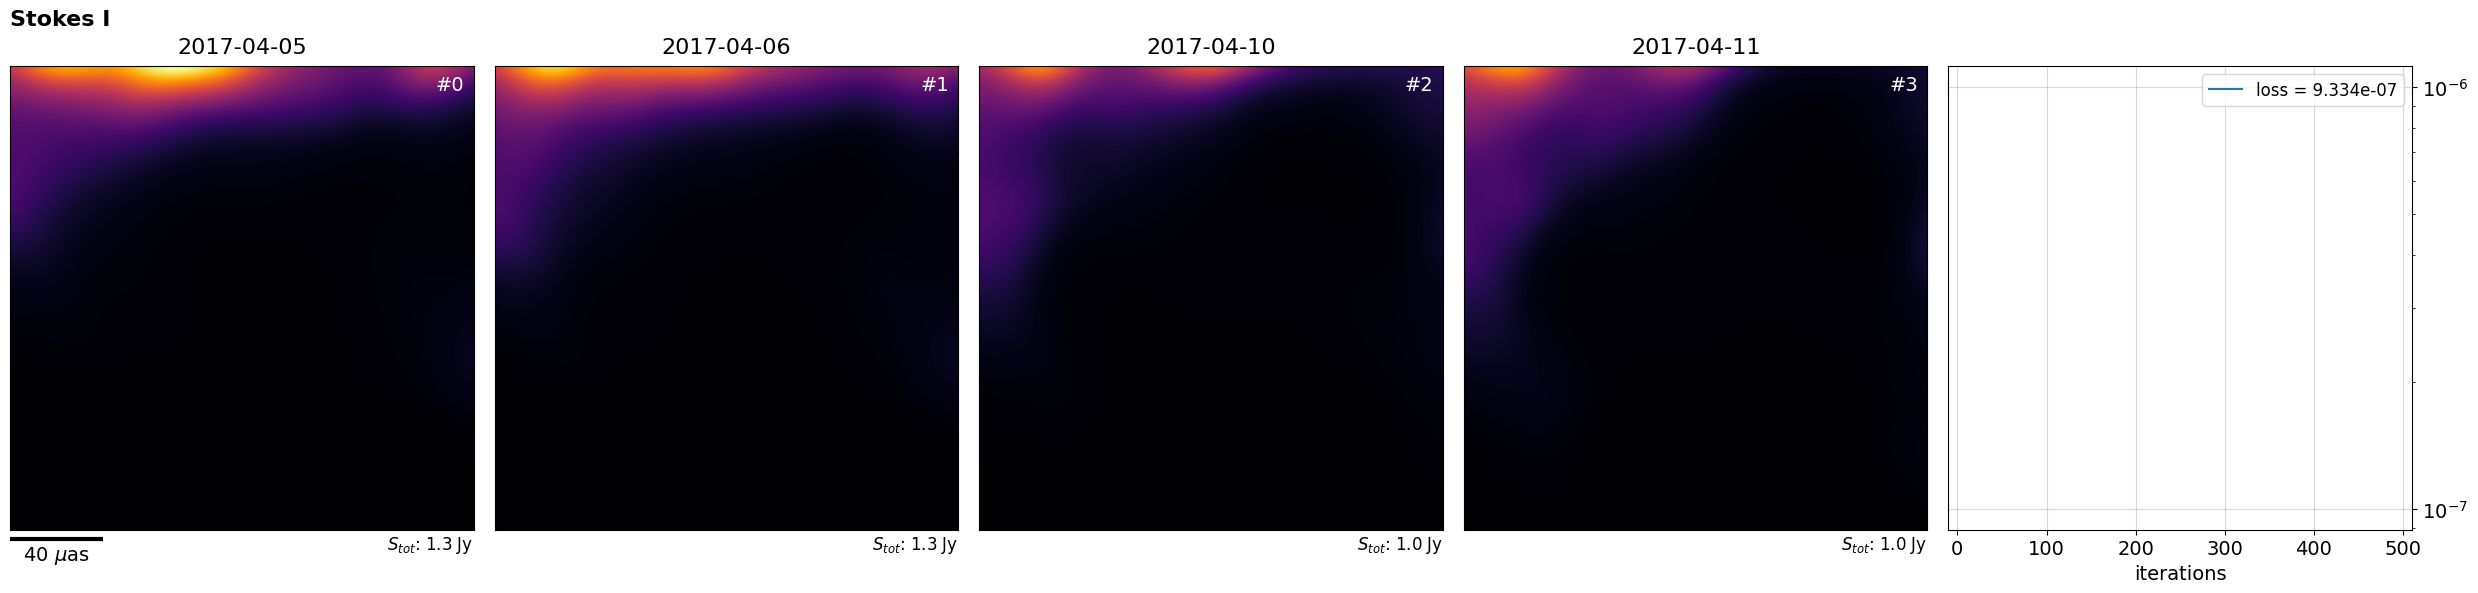

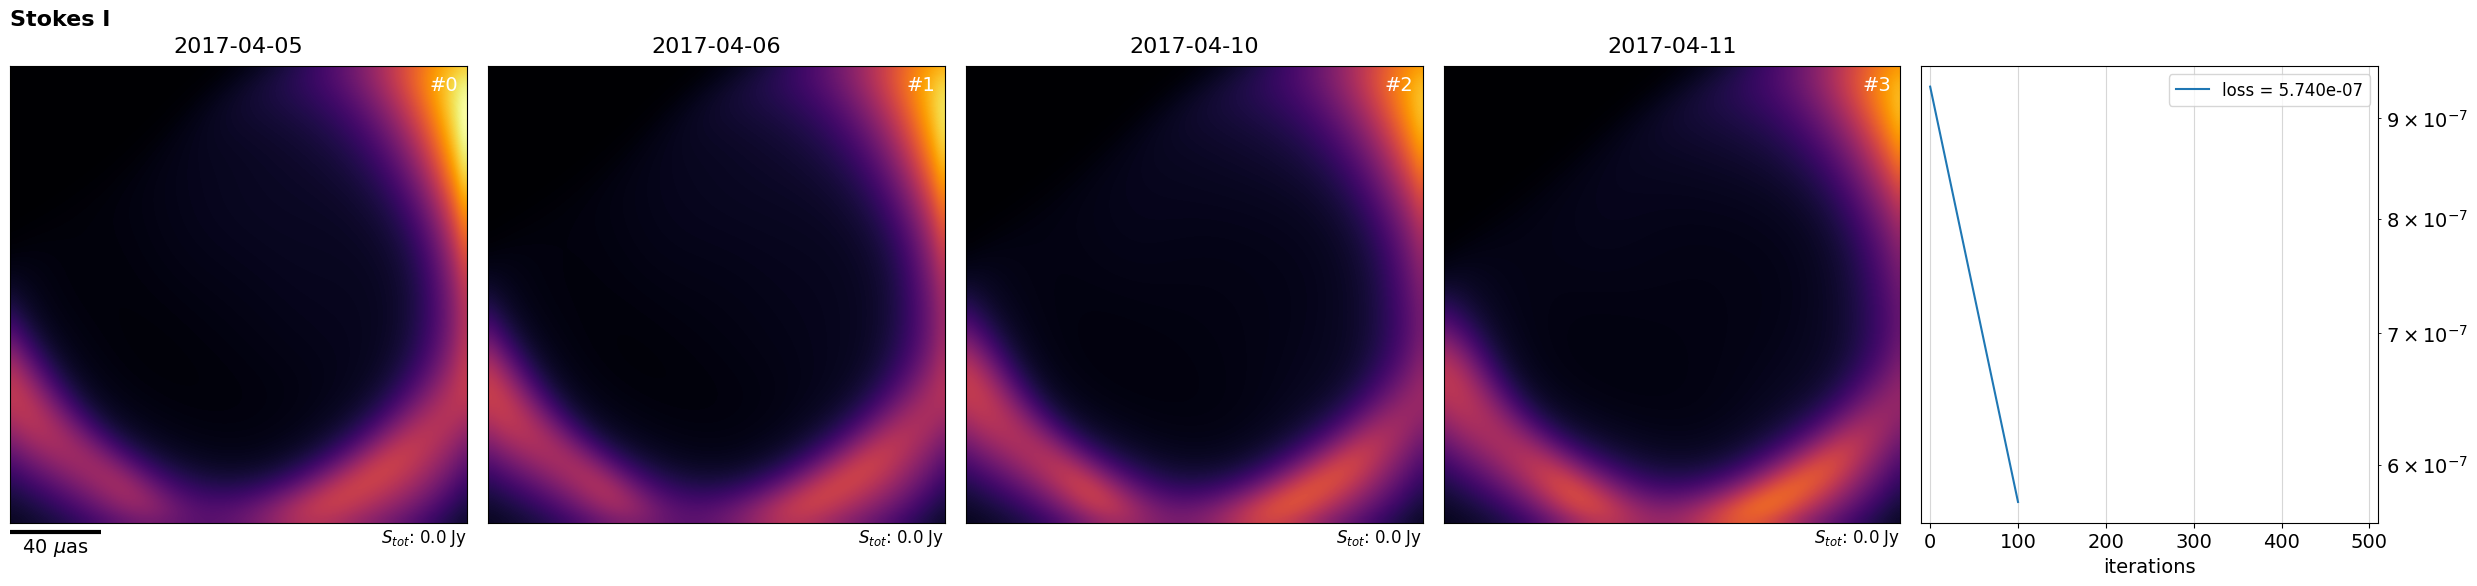

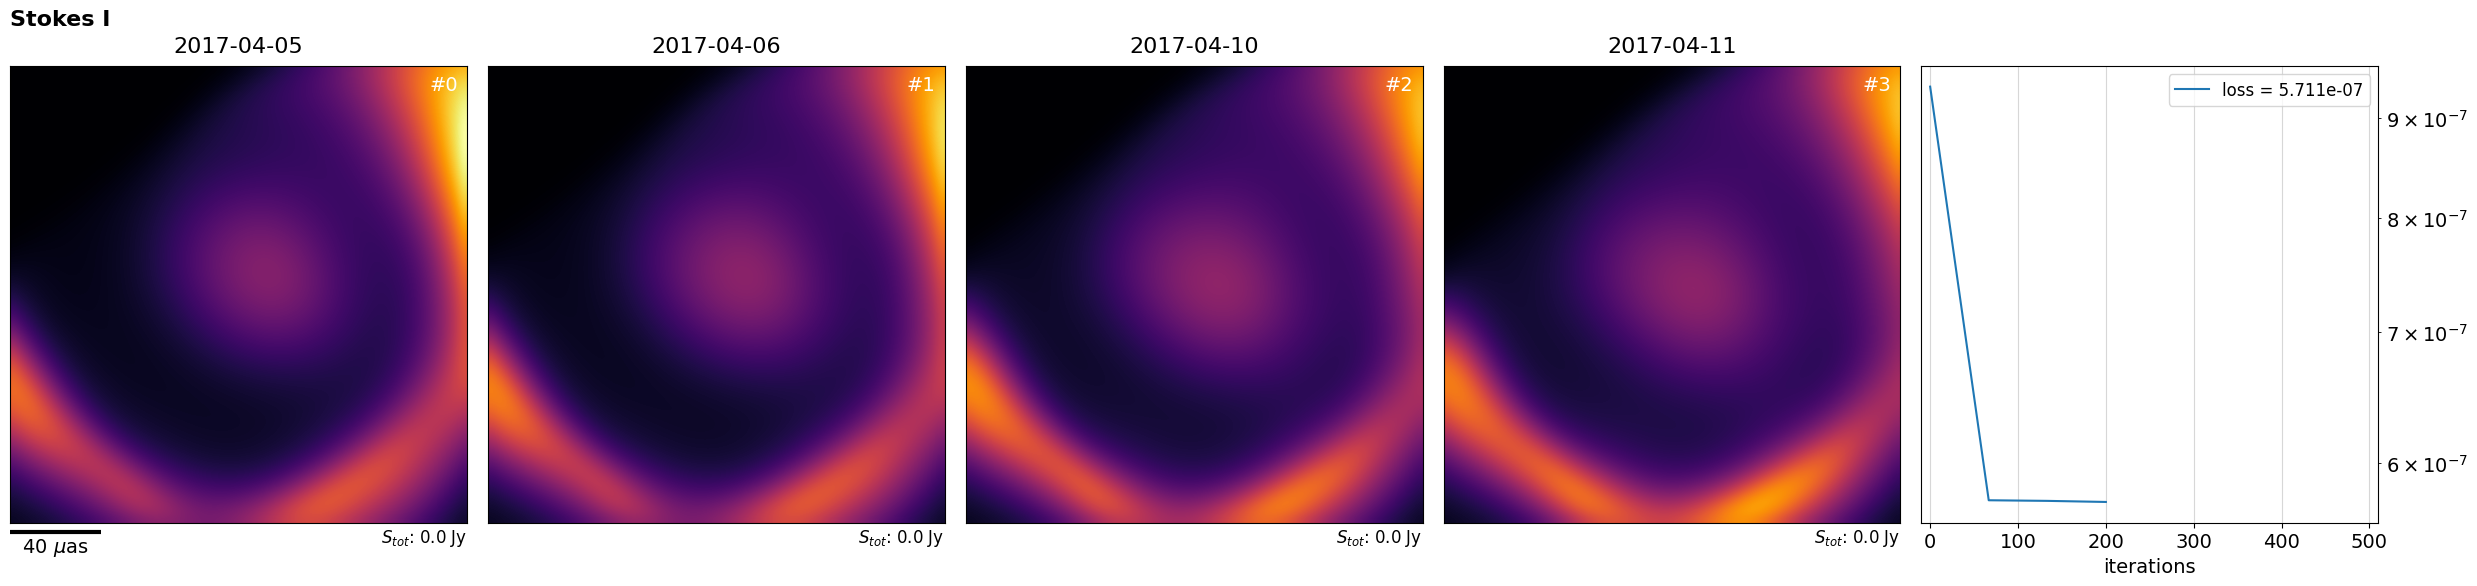

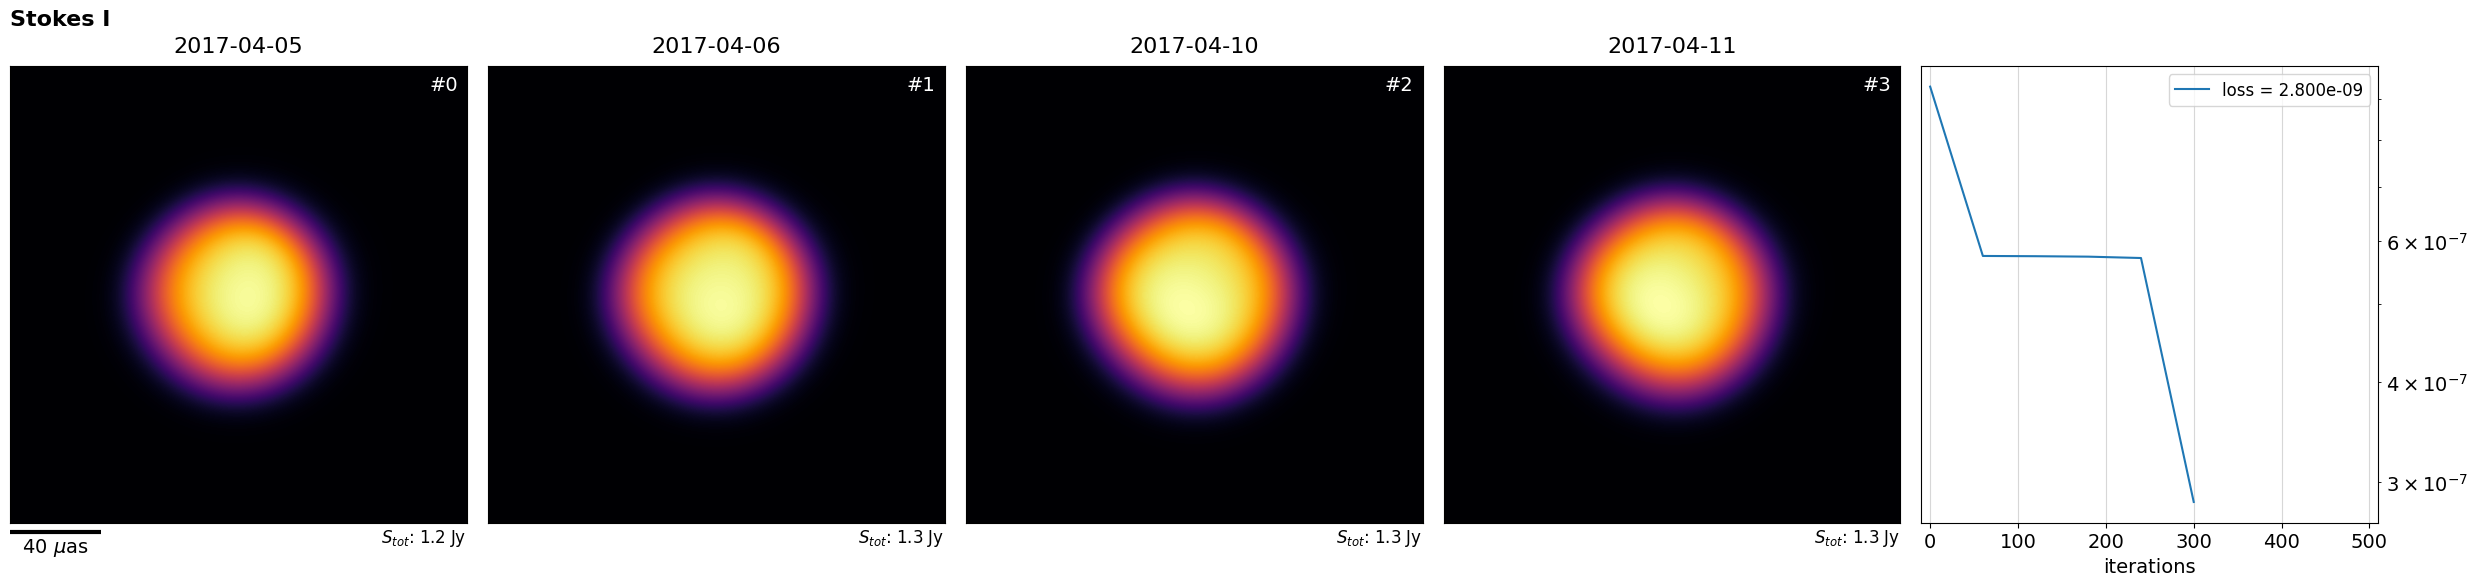

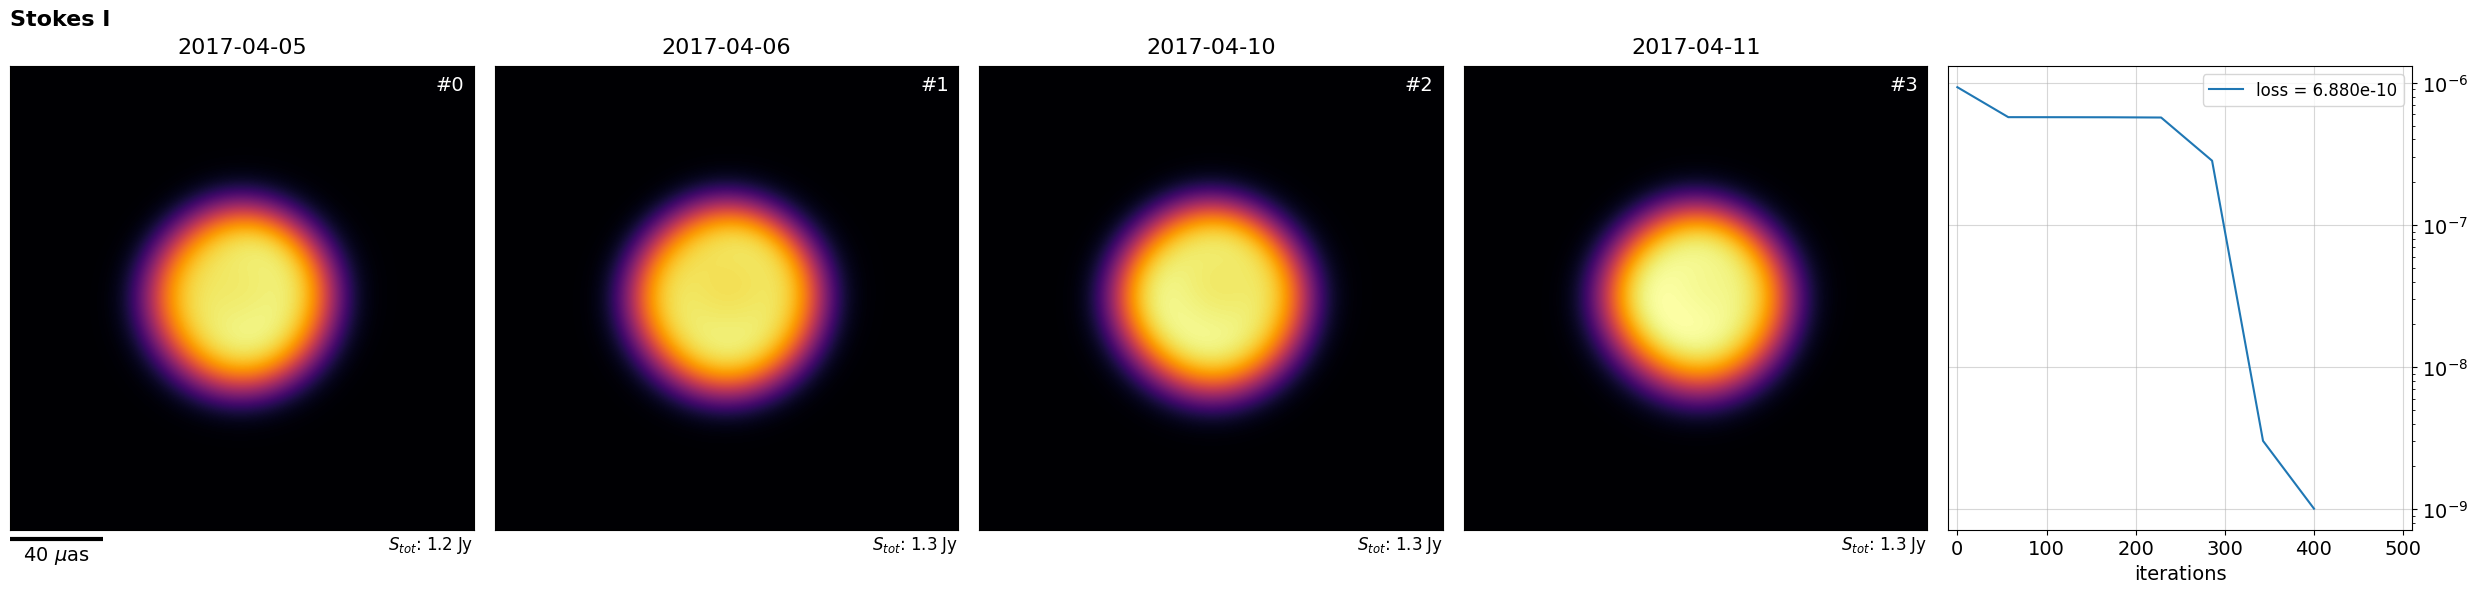

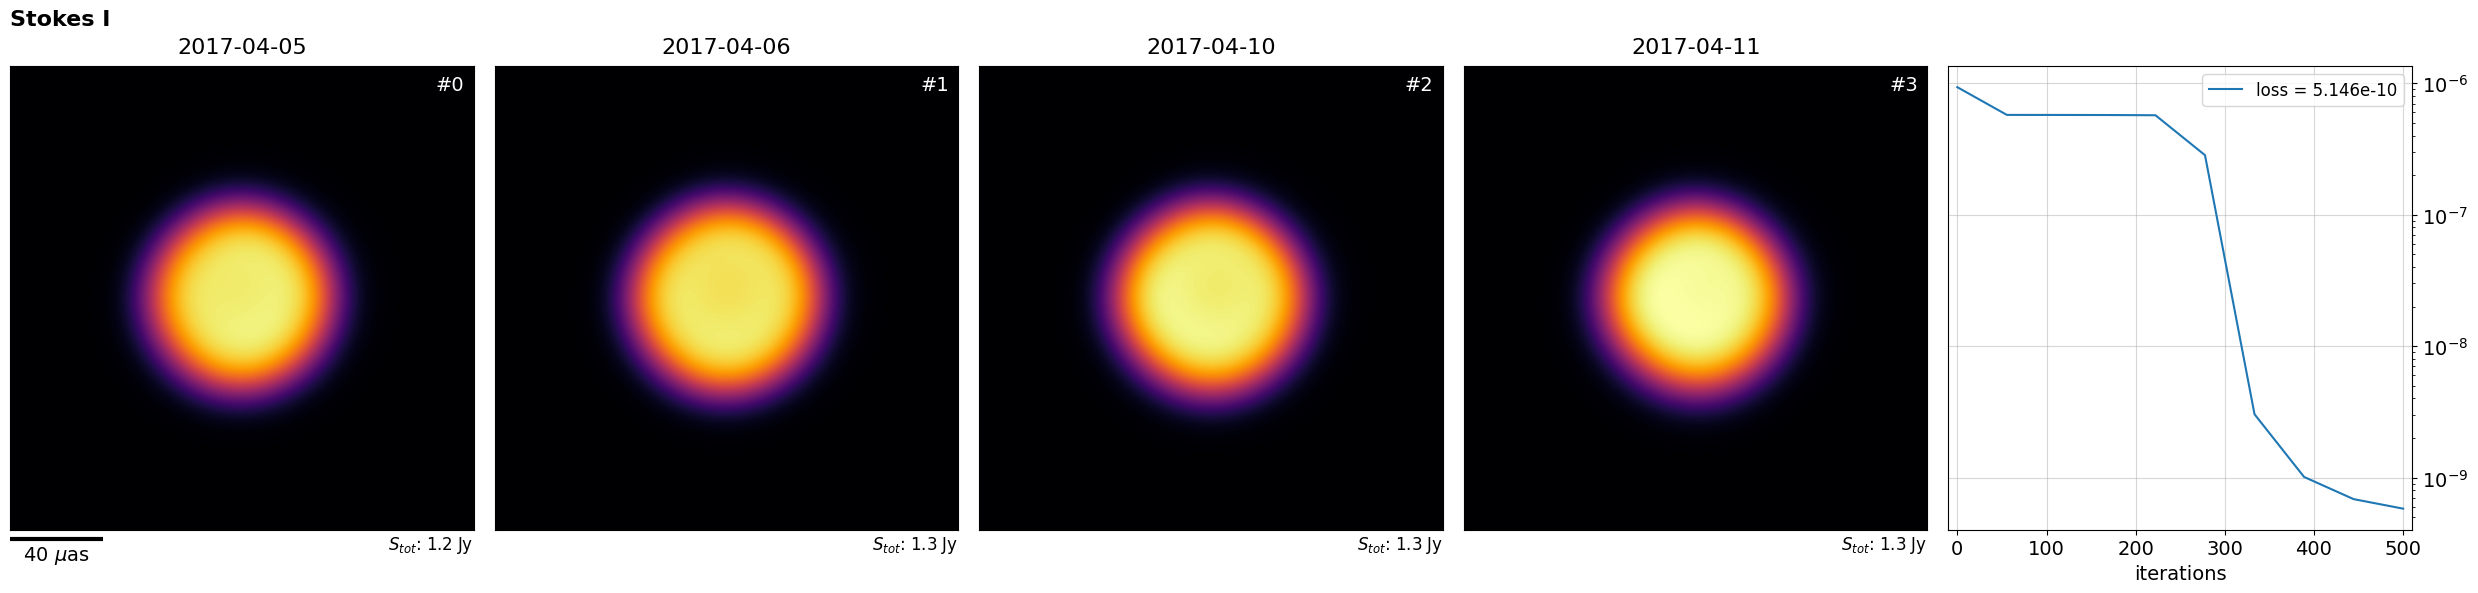

Saving results...


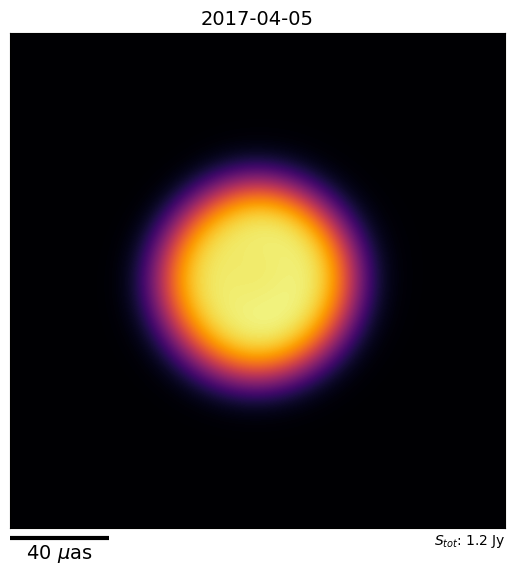

In [ ]:
# Show progress updates
def show_progress(video, outpath):
    video.plot(outpath=outpath)
    from IPython.display import Image as IPImage
    import matplotlib.pyplot as plt
    display(IPImage(outpath))
    plt.close('all')

# Fix jax version issue (Only needed in Colab)
if not hasattr(jax, 'tree_map'):
    jax.tree_map = jax.tree.map

# Create initialization image
init_vid = vi.Video(times, npix, fov, obs.ra, obs.dec, initniter, dates=dates)
init_vid.add_tophat(lcurve, init_params)
init_vid.plot()

# Create empty Video object and initialize loss function
init = vi.Video(times, npix, fov, obs.ra, obs.dec, initniter, dates=dates)
lloss, loss = [], 0

print('Initialization...')

# Initialization training
for i in (pbar := tqdm(range(1, initniter+1))):
    pbar.set_description(f'Loss {loss:.1e}')

    # Apply one training step
    loss, _, out, state = tr.Trainer.train_step(
        odict(
            state=state,
            grid=grid,
            init_vid=init_vid.iarr
        )
    )

    # Save loss
    lloss.append(loss)

    # Show initialization progress
    if i == 1 or i % 100 == 0 or i == initniter:
        init.from_video(out, loss=lloss)
        show_progress(video=init, outpath='./M87init.png')

# Save initialized output
print('Saving results...')
init.from_video(out, loss=lloss)
init.plot_gif(outpath='./M87init.gif')



### Step 5: Run the optimization

Training...


  0%|          | 0/2000 [00:00<?, ?it/s]

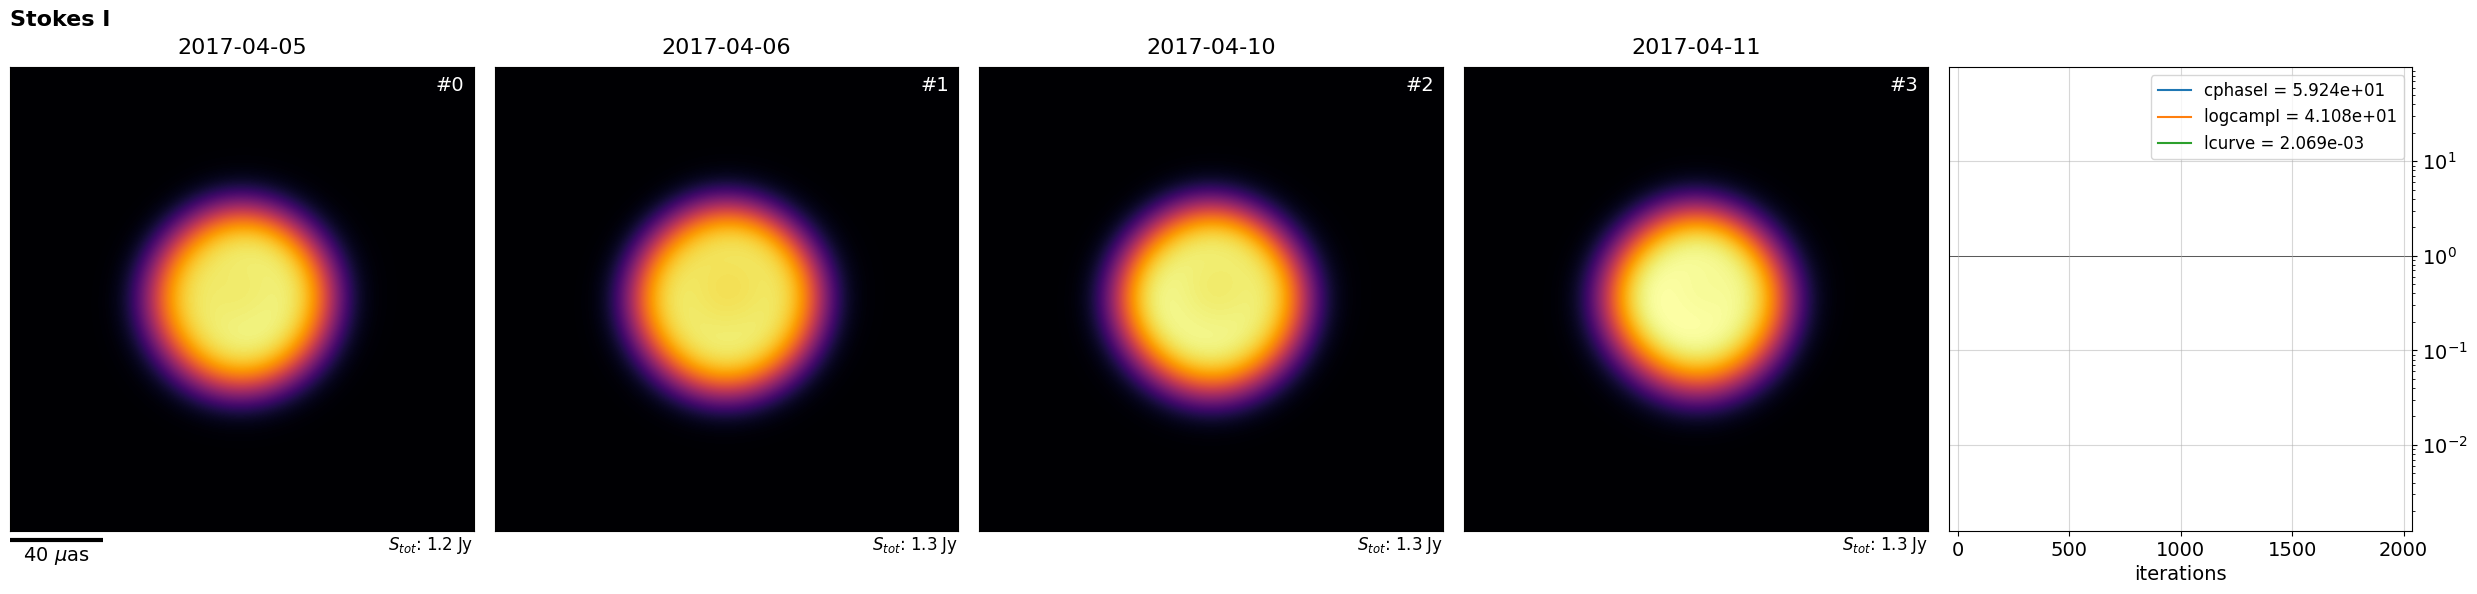

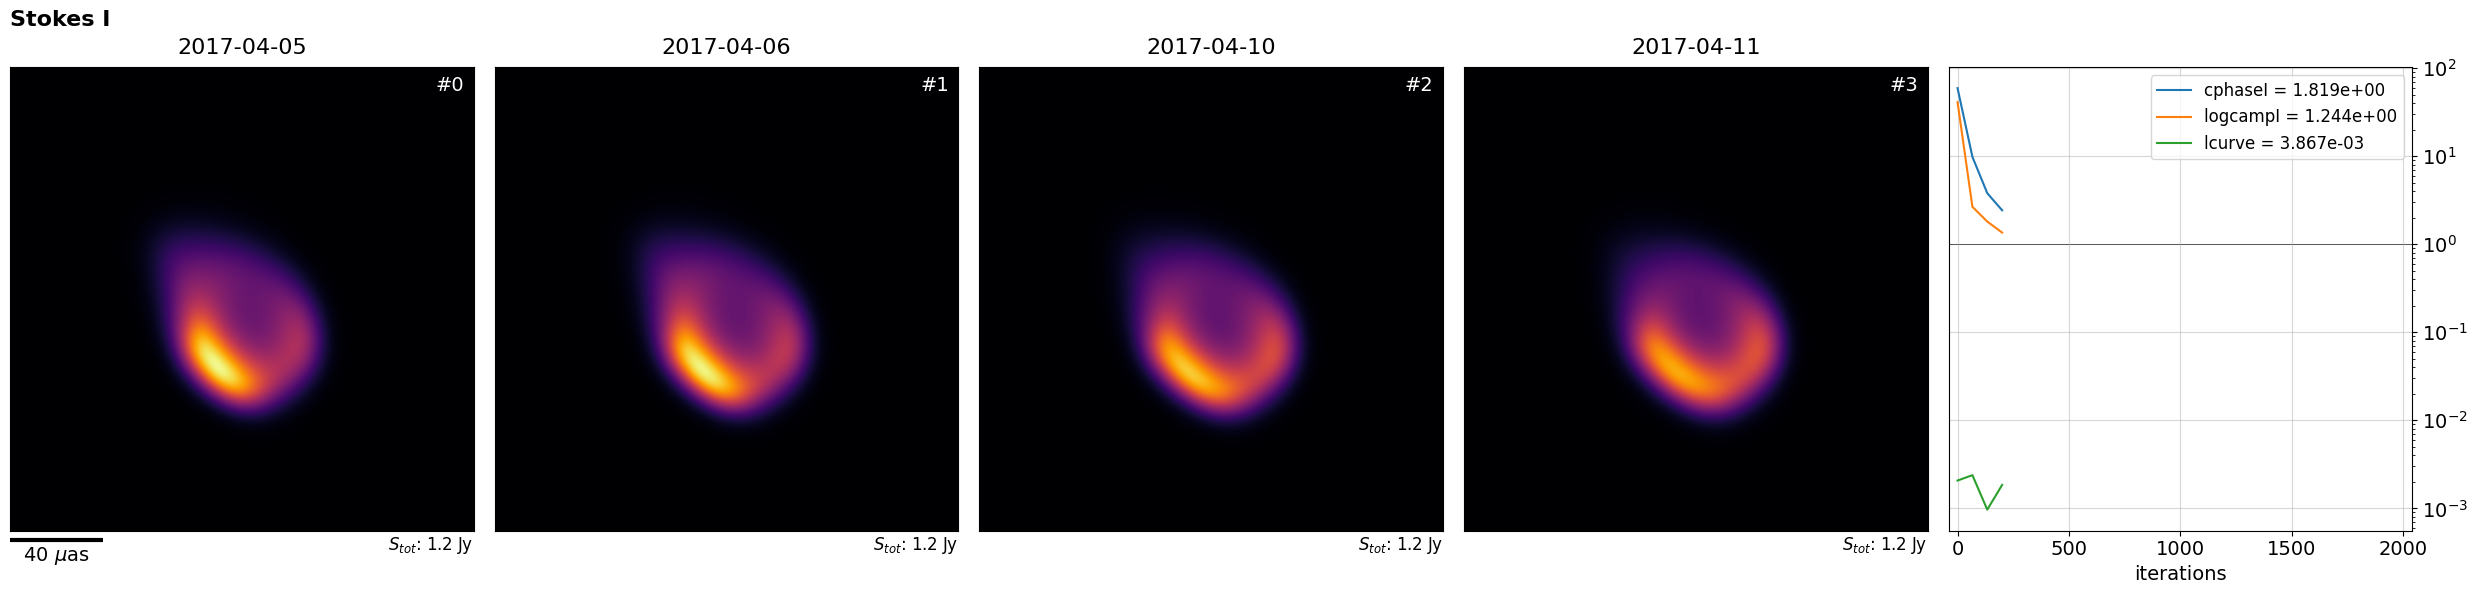

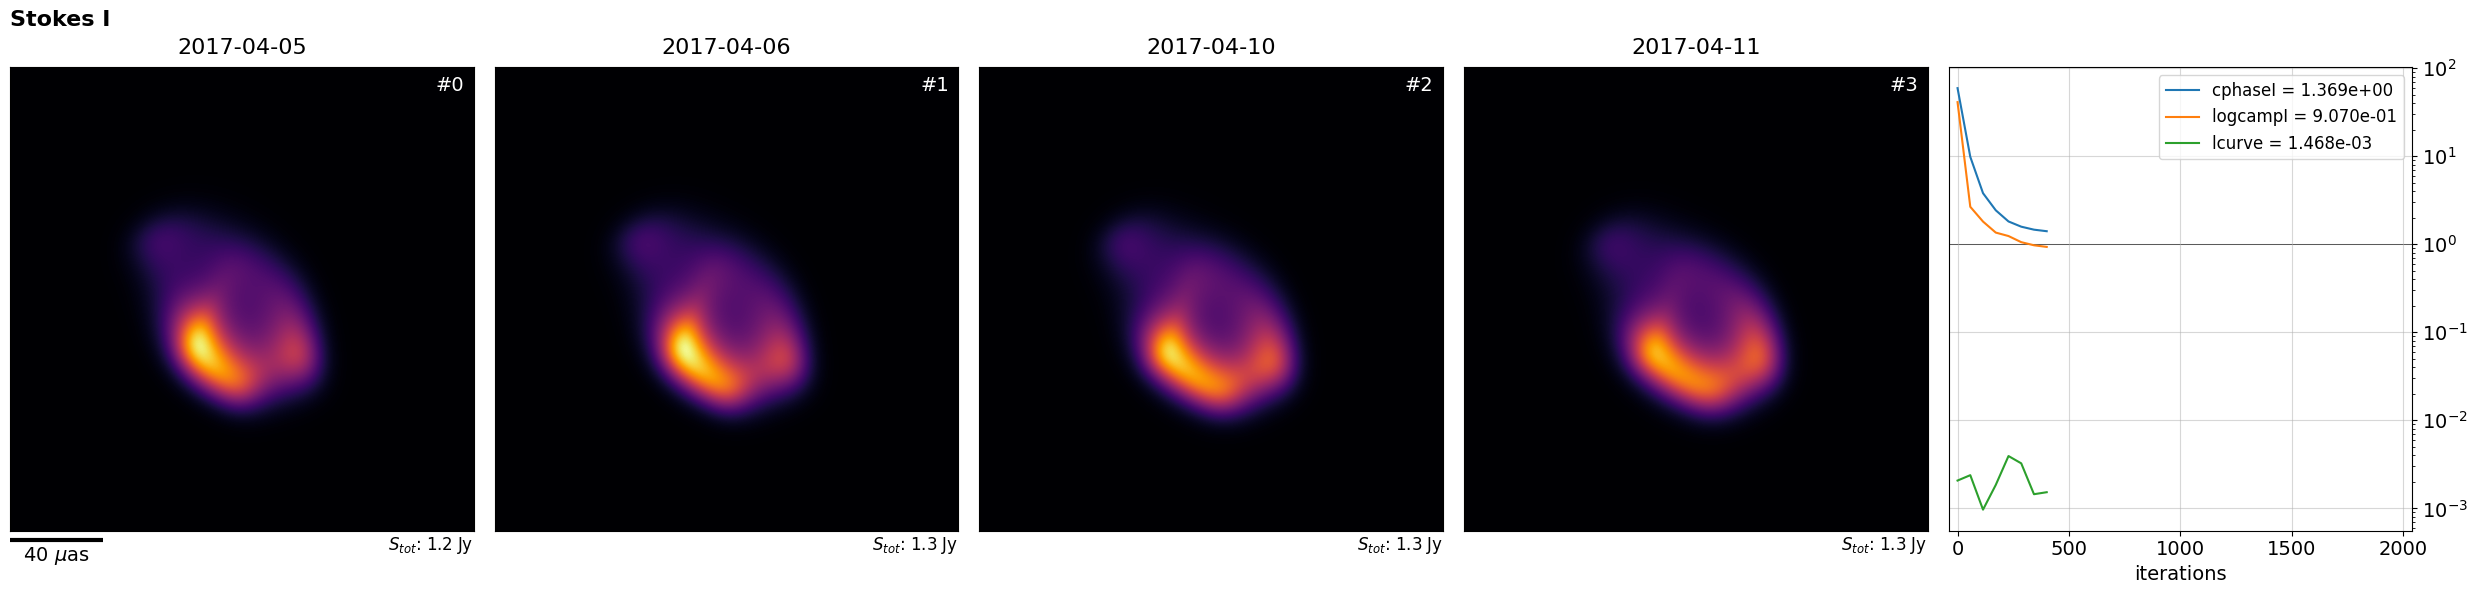

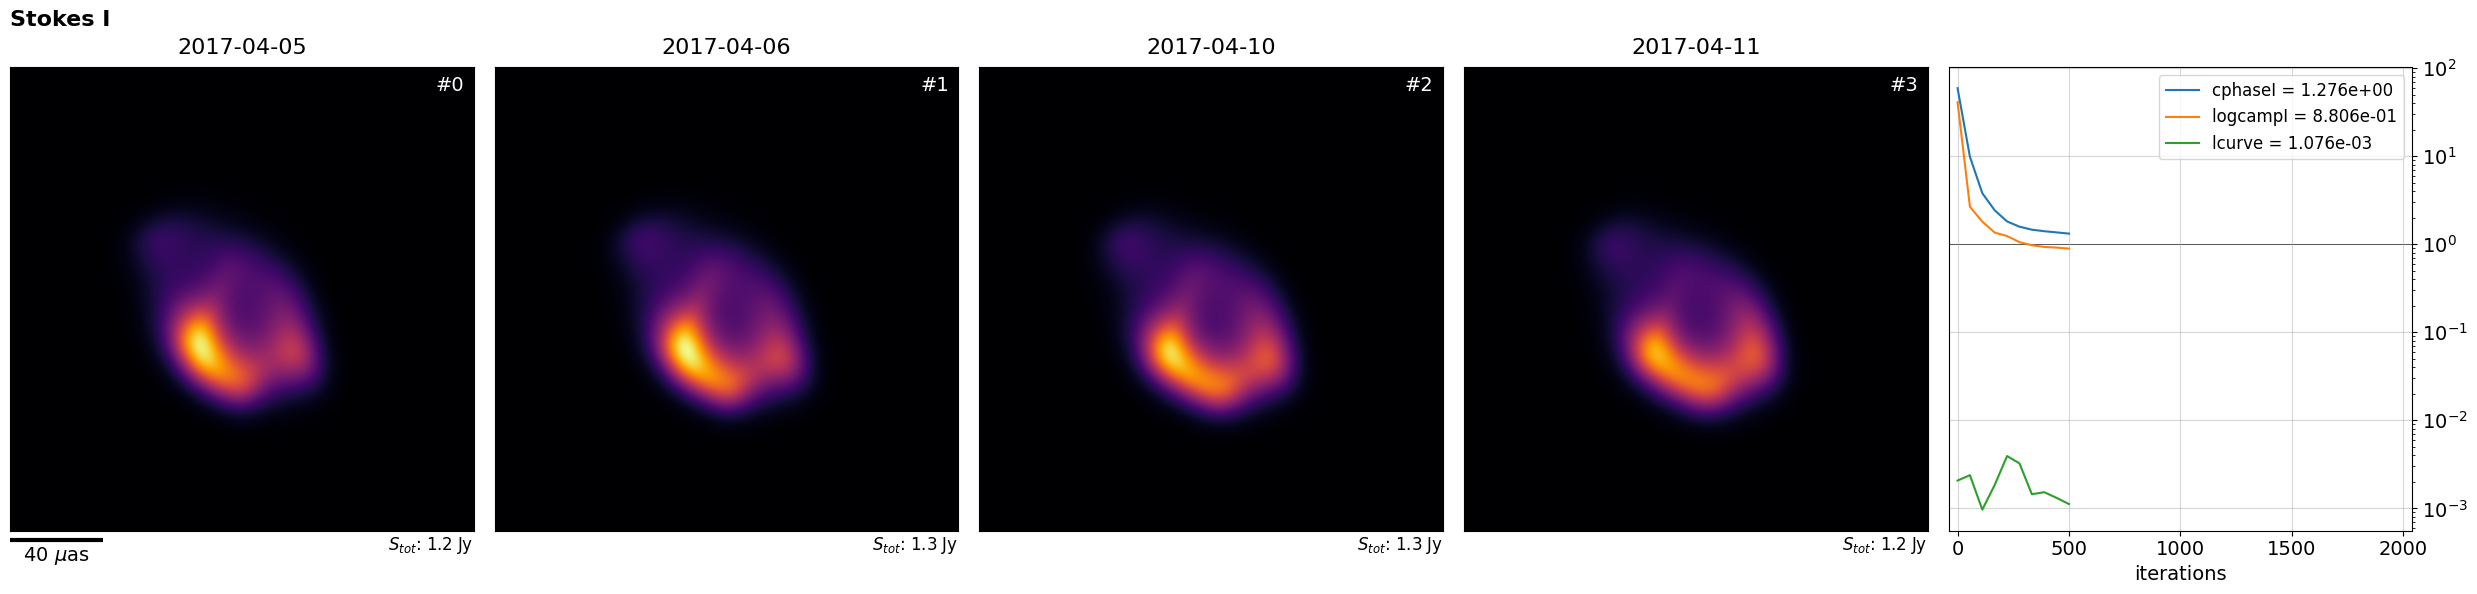

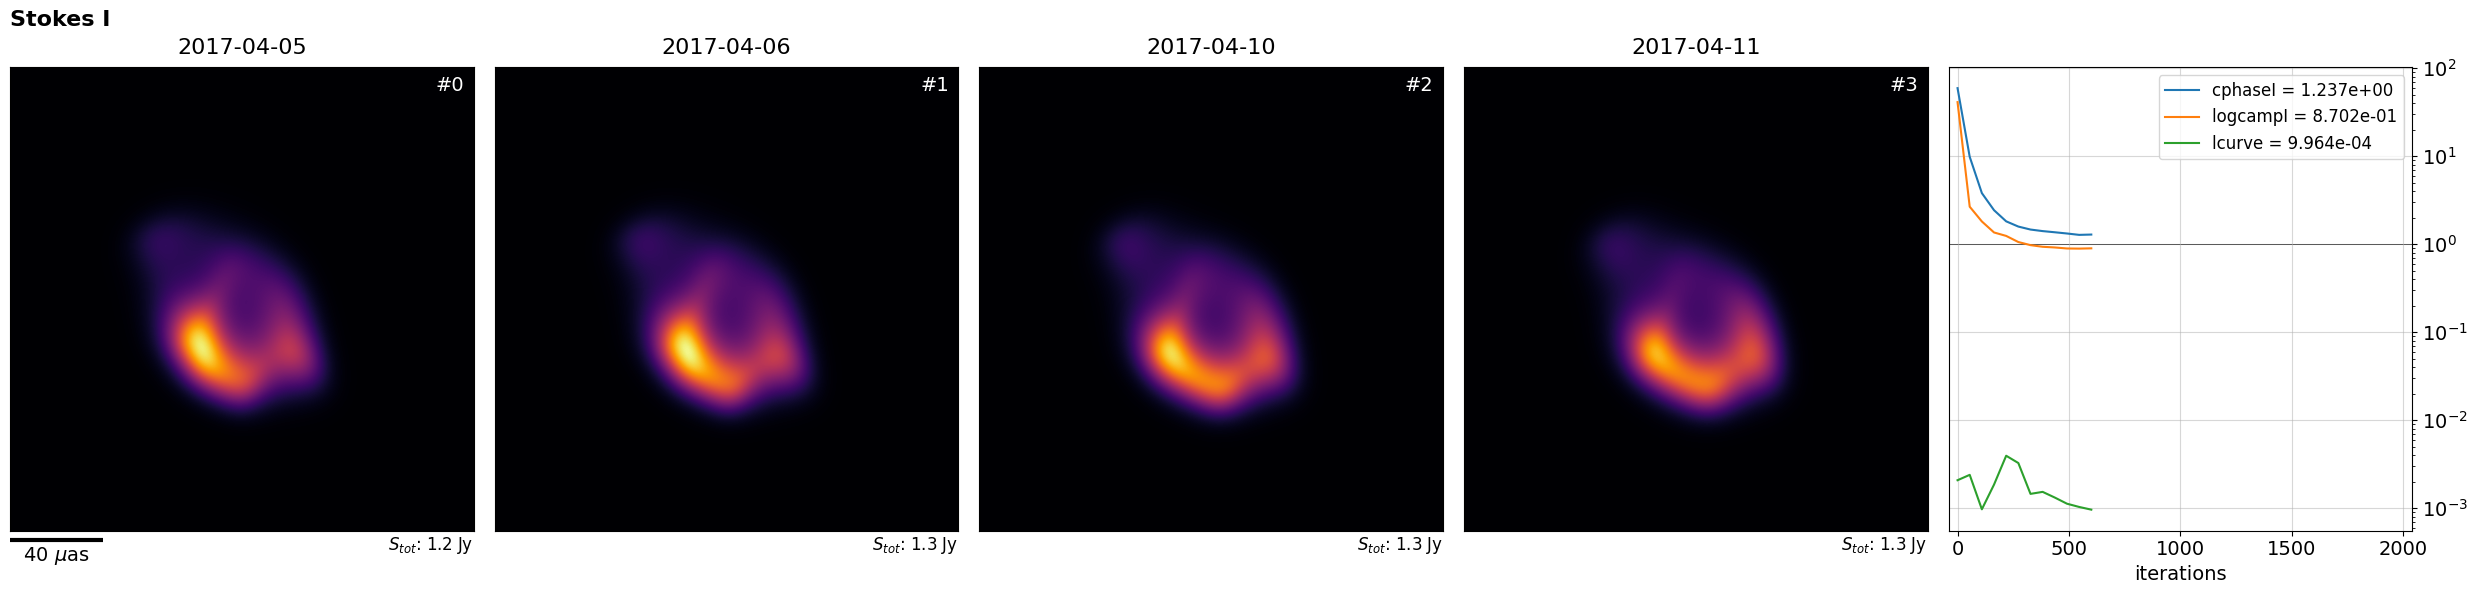

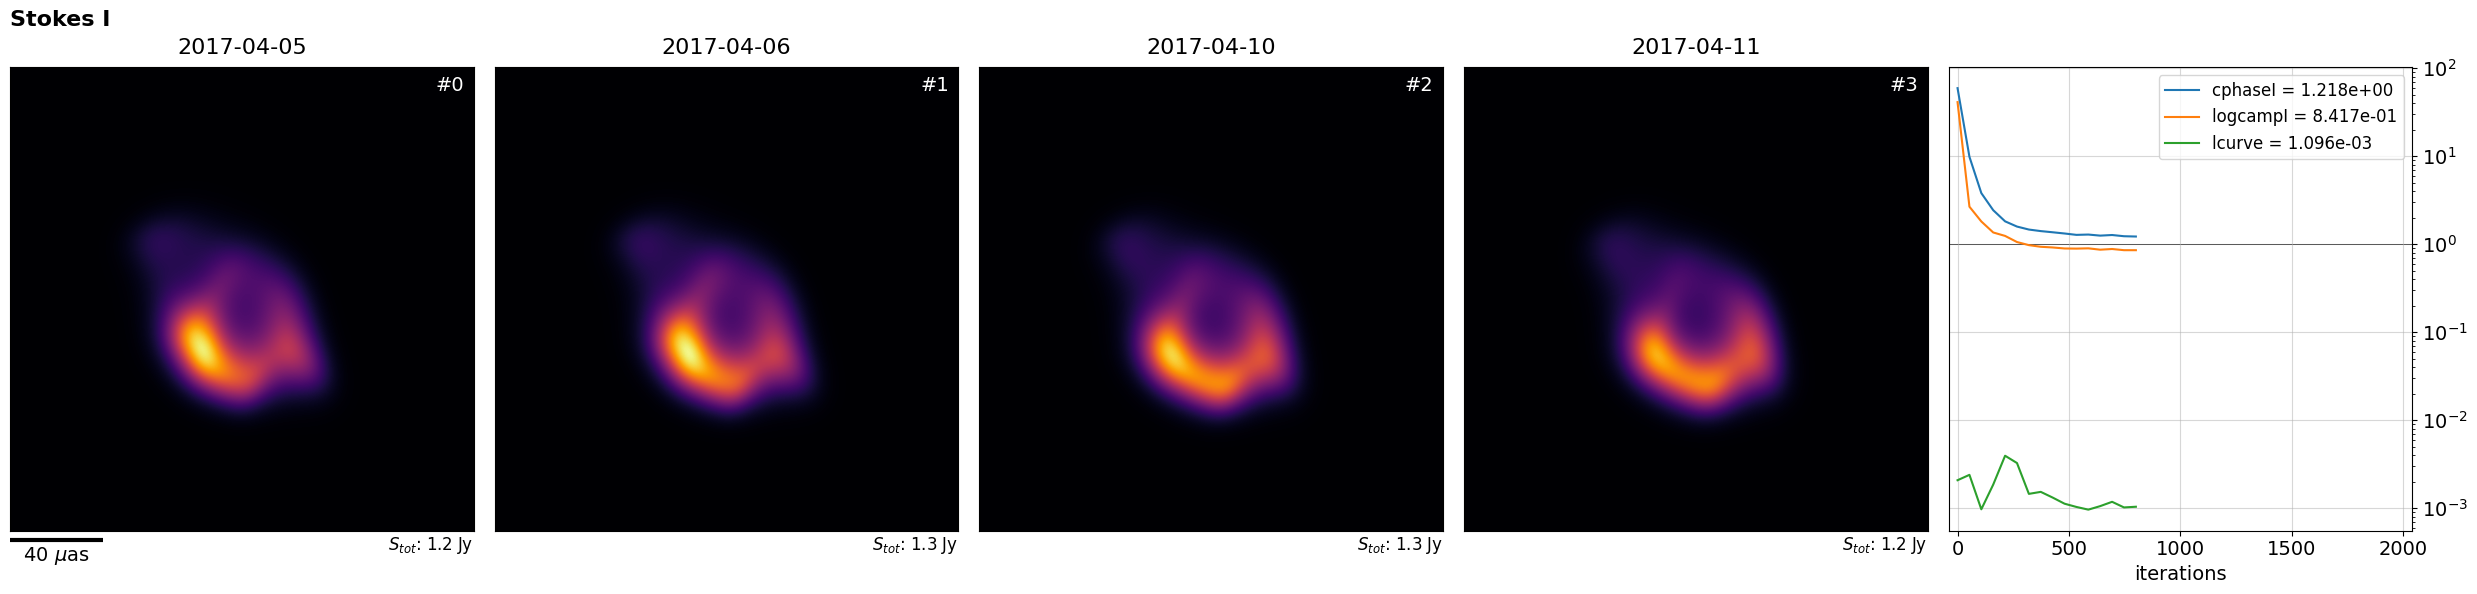

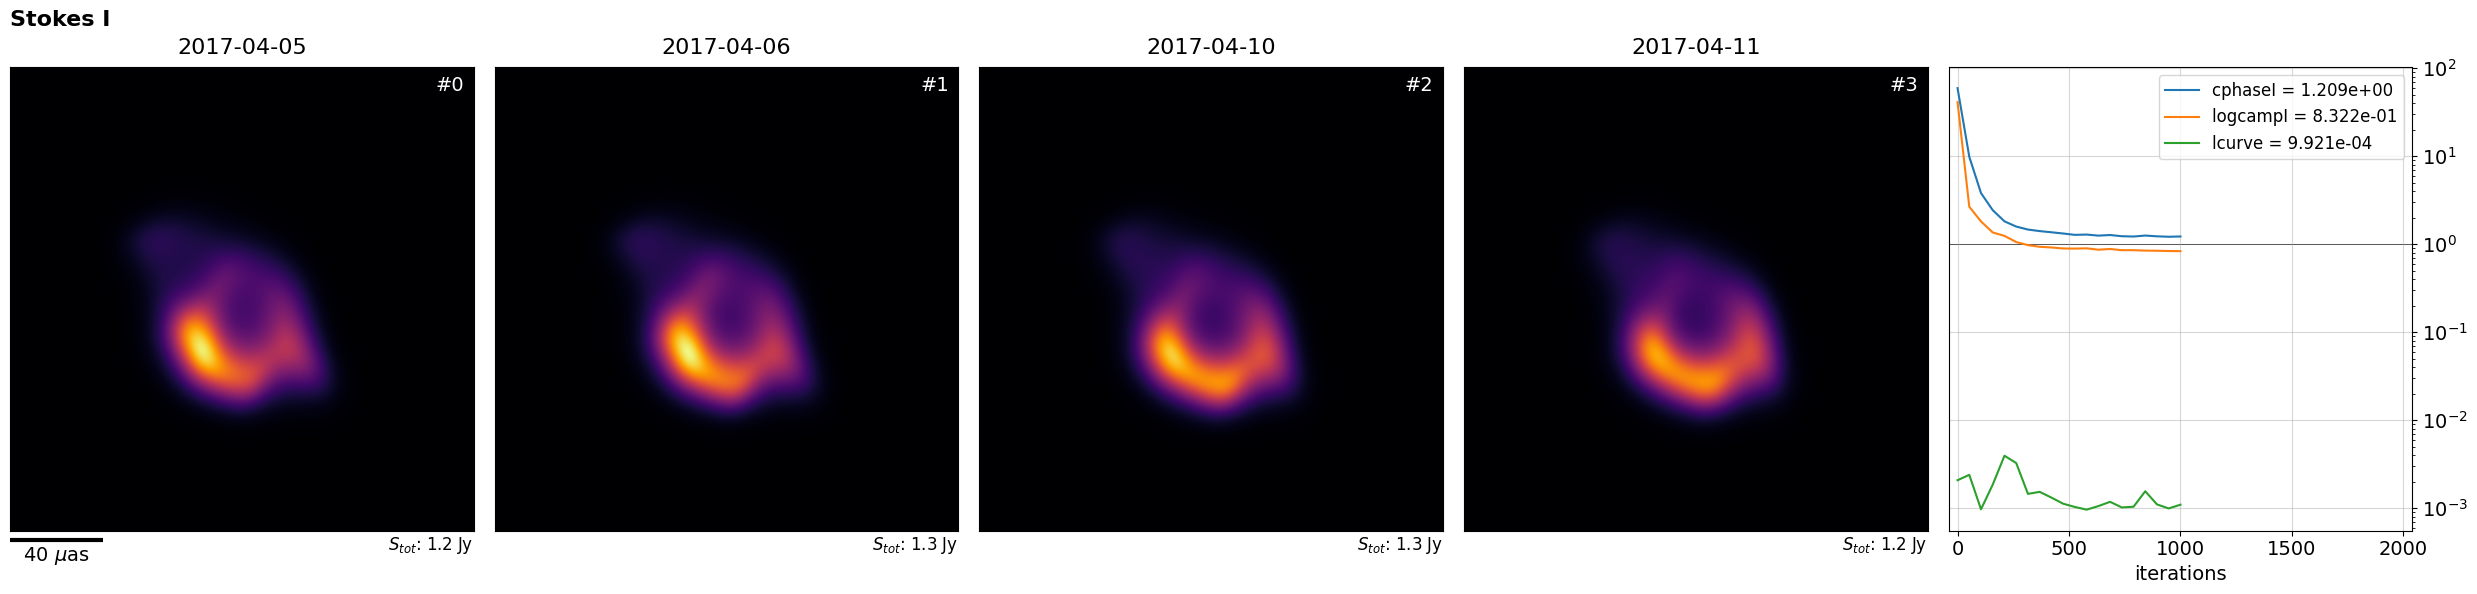

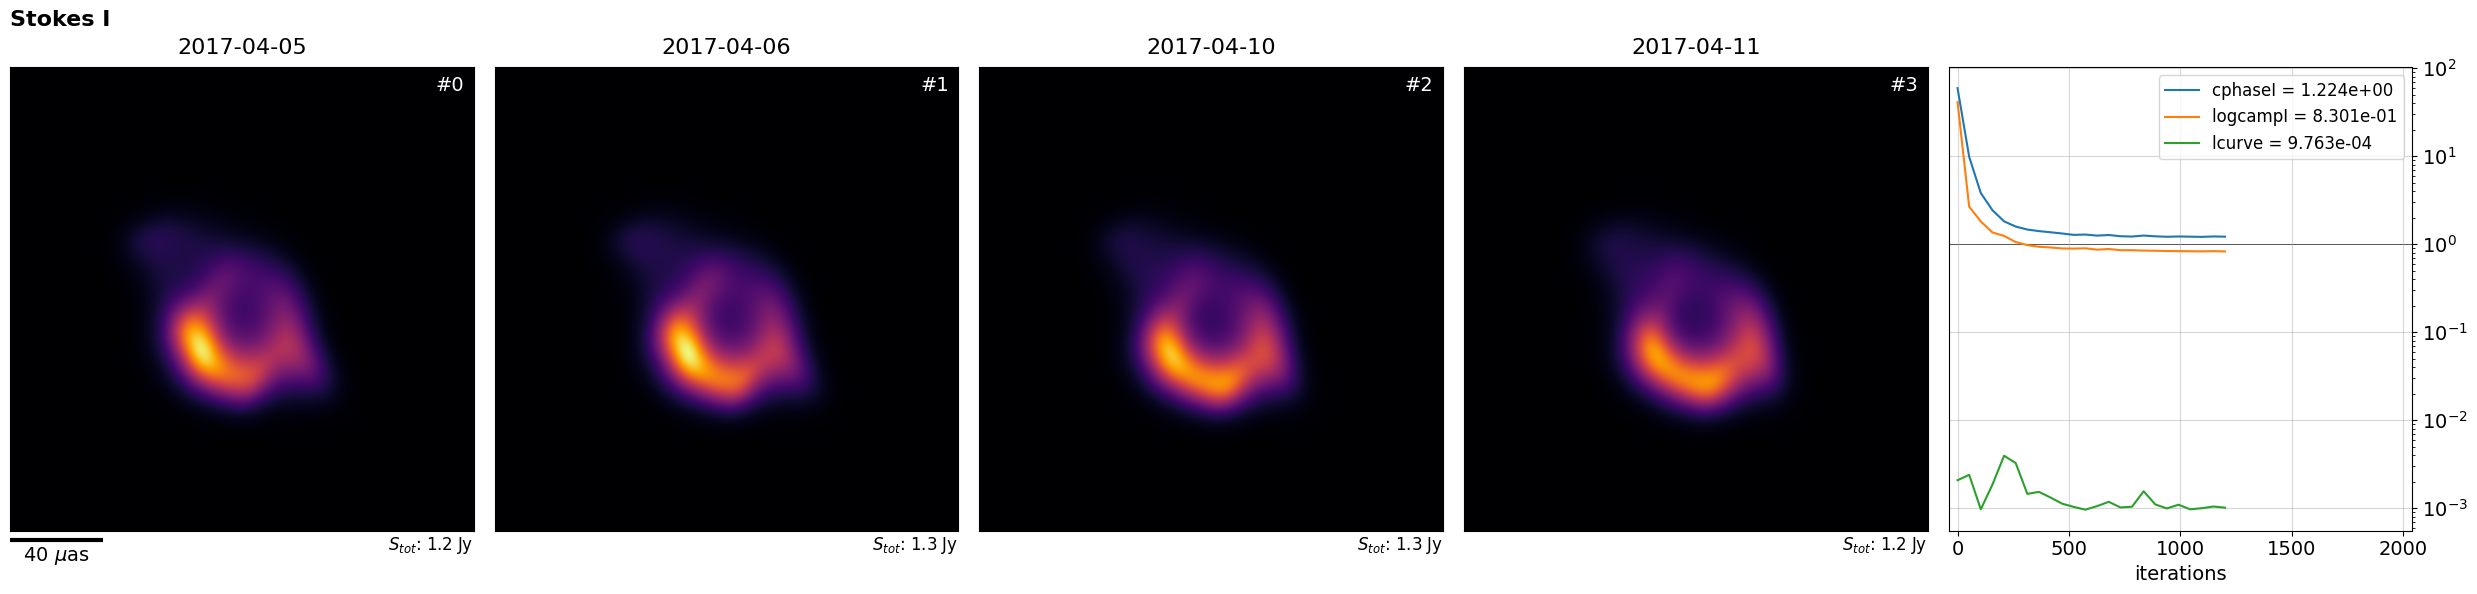

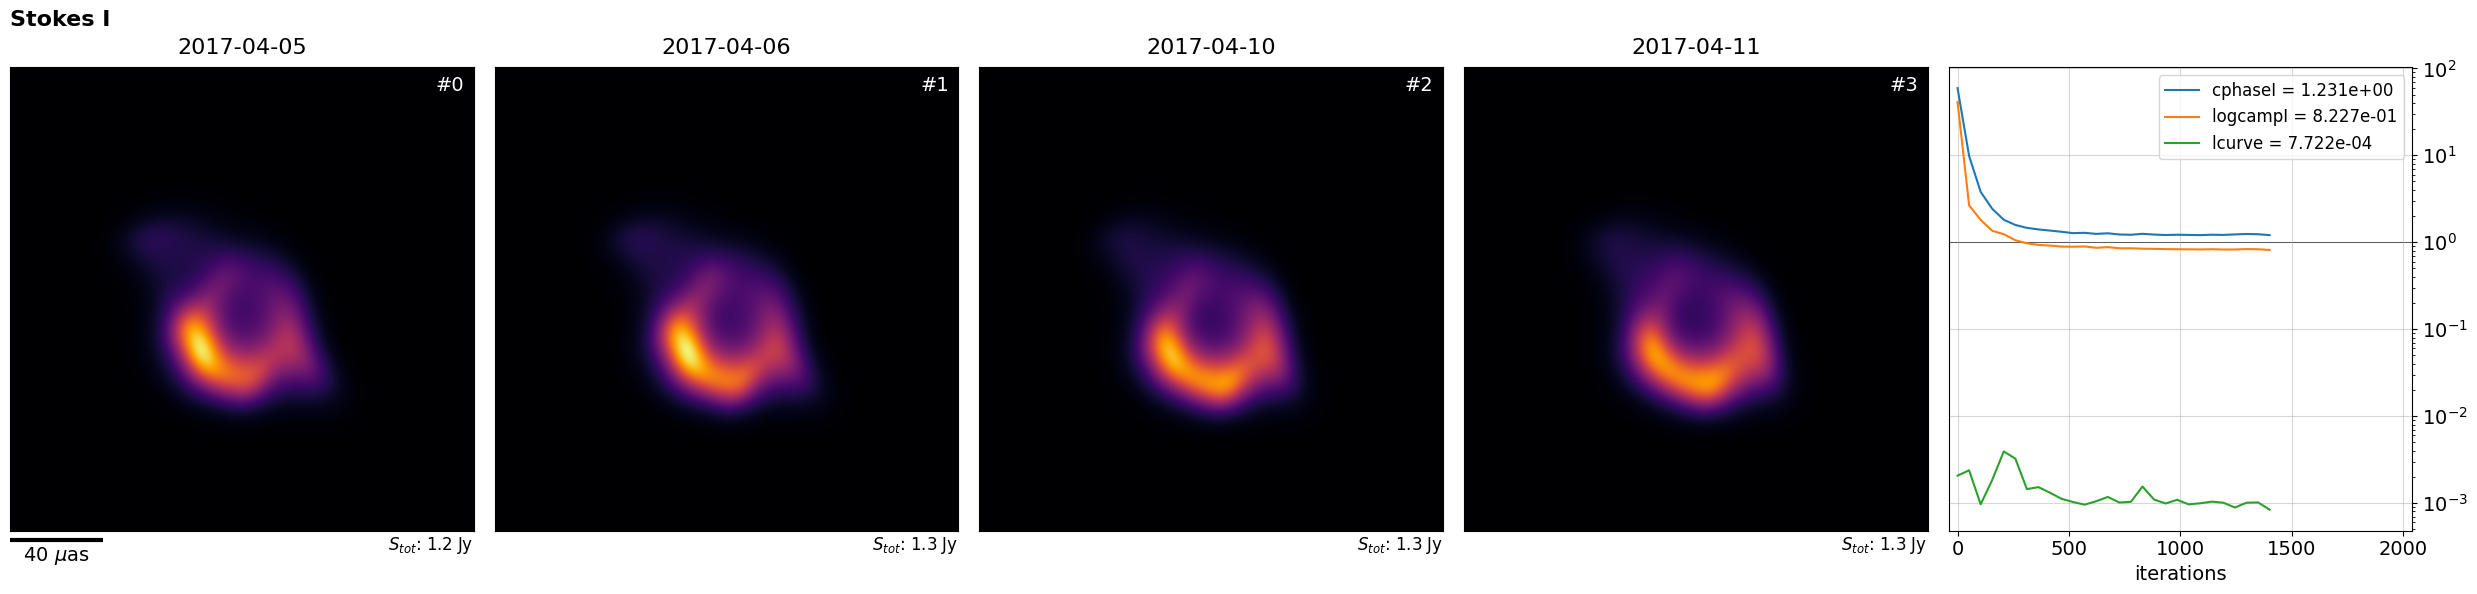

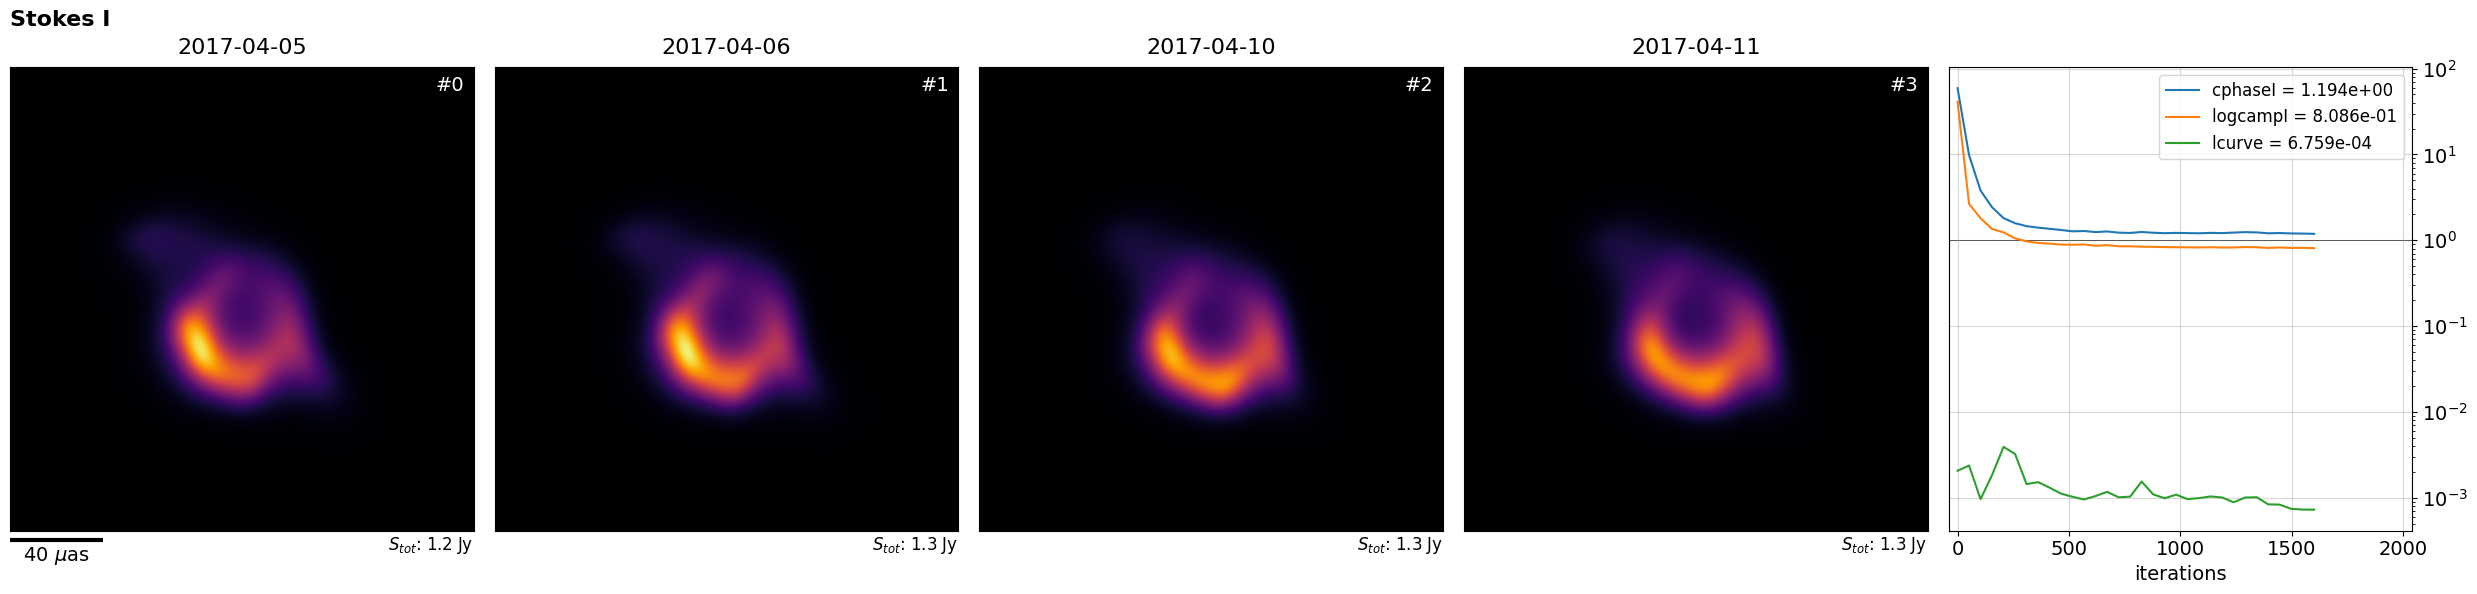

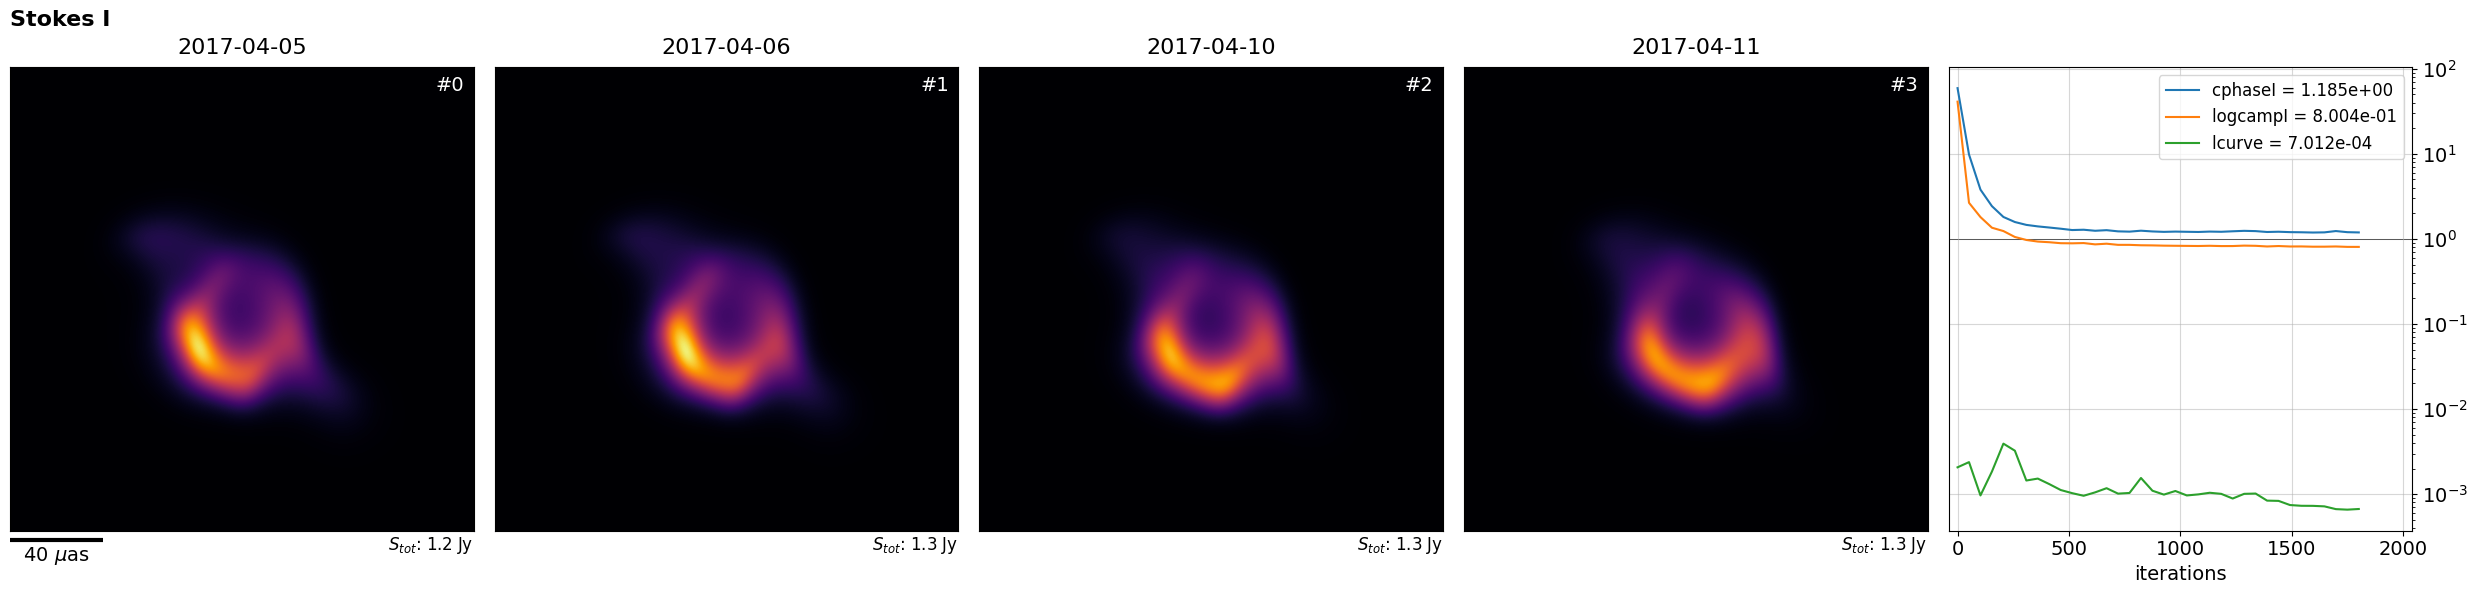

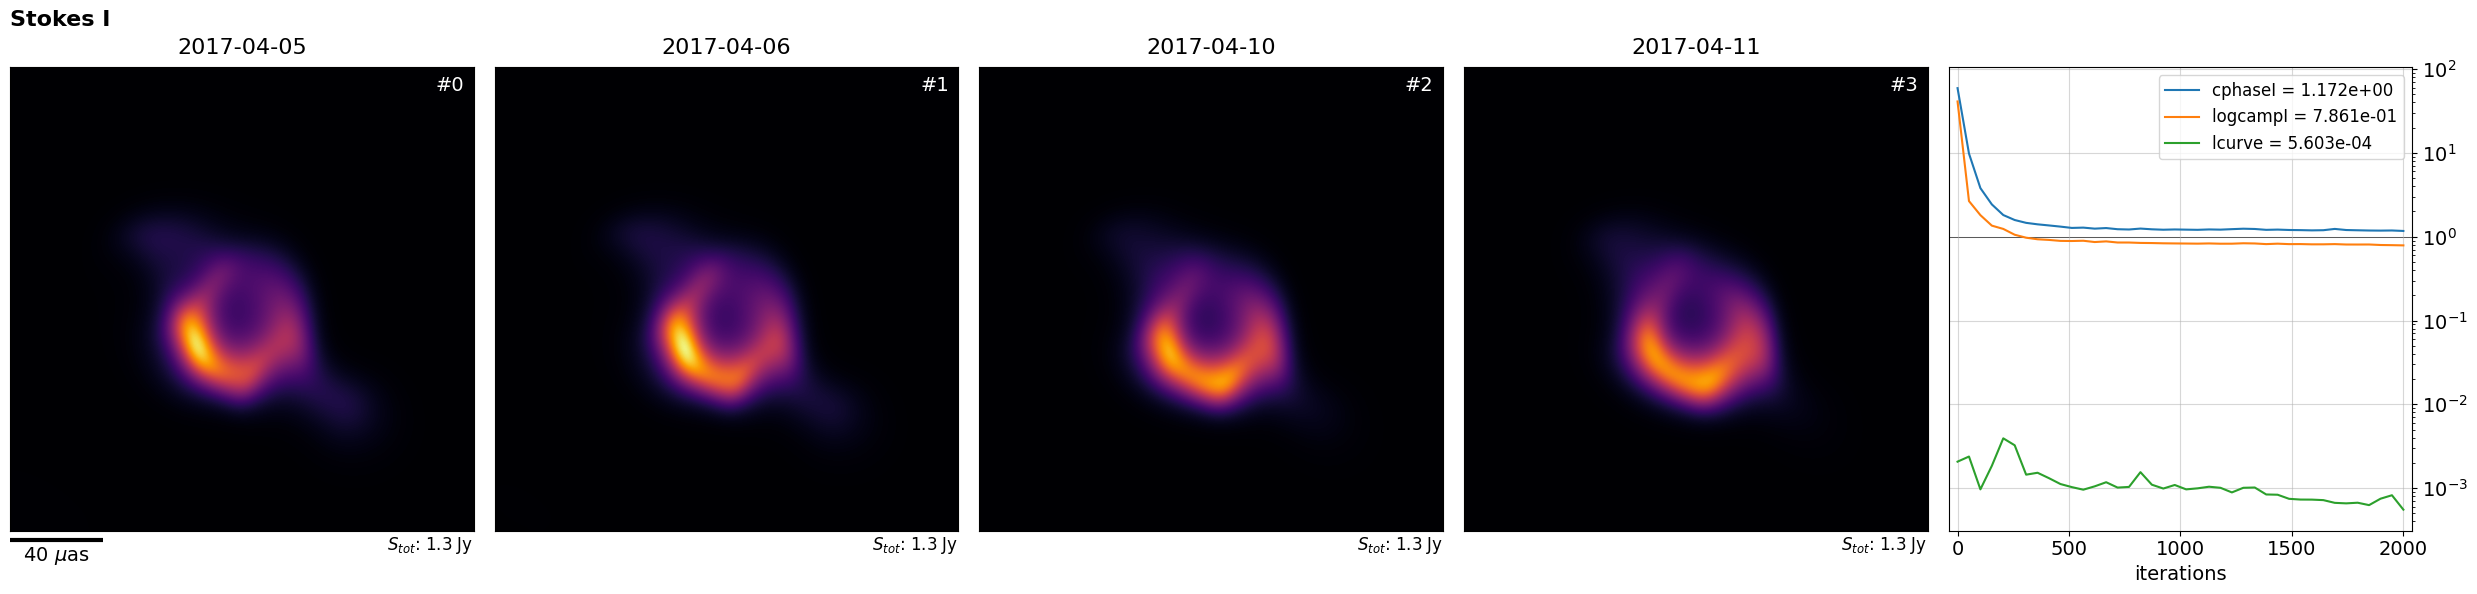

In [ ]:
# Create empty Video object and initialize loss function
video = vi.Video(times, npix, fov, obs.ra, obs.dec, niter, dates=dates)
lloss, loss = {dp: [] for dp in data_prod} | {'lcurve': []}, 0

print('Training...')

# Optimization training
for i in (pbar := tqdm(range(1, niter+1))):
    pbar.set_description(f'Loss {loss:.1e}')

    # Apply one training step
    loss, ldict, out, state = tr.Trainer.train_step(
        odict(
            state=state,
            grid=grid,
            data=data,
            lcurve=lcurve,
        )
    )

    # Save loss
    for l in lloss.keys():
        lloss[l].append(ldict[l])

    # Show initialization progress
    if i == 1 or i % 200 == 0 or i == initniter:
        video.from_video(out, loss=lloss)
        show_progress(video=video, outpath='./M87video.png')

### Step 6: Save the final video
1. Save the output video with one frame per day
2. Resample the network at different times and save the continuous version of the video

Saving results...


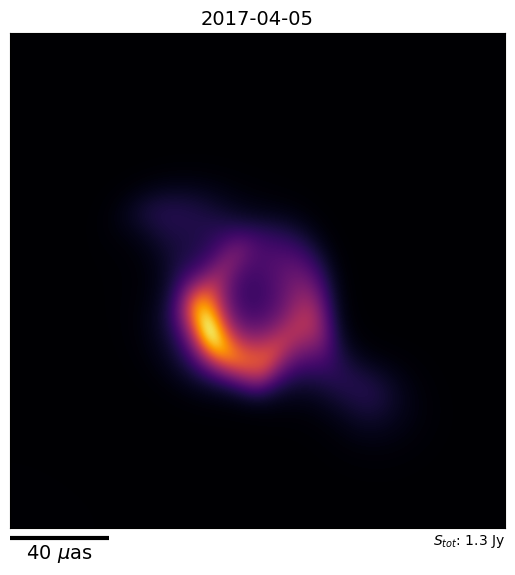

In [ ]:
# Save optimized video
print('Saving results...')
video.from_video(out, loss=lloss)
video.plot_gif(outpath='./M87video.gif')

Re-sampling the network on different time stamps


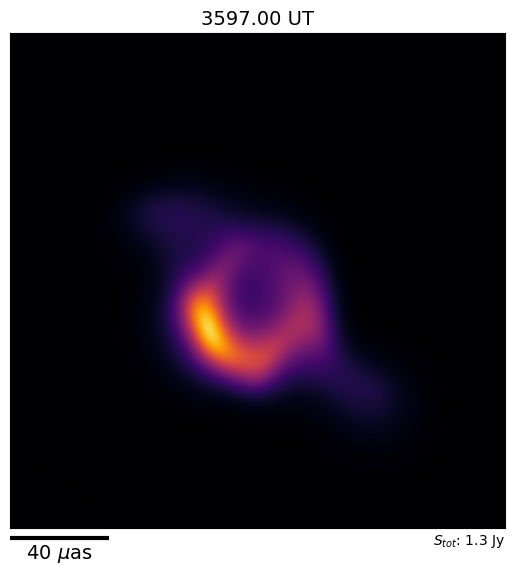

In [ ]:
print('Re-sampling the network on different time stamps')
times_new = np.linspace(times[0],times[-1], 20)
ntimes_new = len(times_new)
grid_new = ut.get_grid(npix, npix, ntimes_new, times=times_new)
video = vi.Video(times_new, npix, fov, obs.ra, obs.dec, niter)
video.from_state(state, grid_new)
video.plot_gif(outpath='./M87video_resampled.gif')